In [2]:
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260408-25992-qcodes.log
Experiment loaded. Last ID no: 145


# Device Names

In [3]:
device_name_1 = 'Line 1 R7C6'
device_name_2 = 'Line 2 Old Device'

# 8/4/26

Text(0, 0.5, 'V')

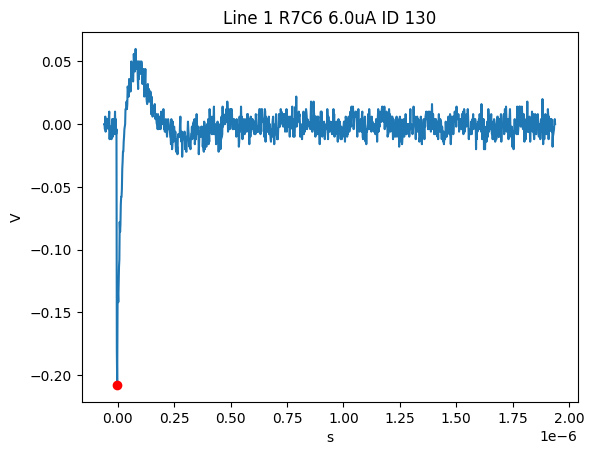

In [7]:
ID = 130

data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current'][0]
trace = data['trace']['trace']
time_axis = data['trace']['time_axis']

peak = np.where(trace == min(trace))

plt.plot(time_axis, trace)
plt.plot(time_axis[peak], trace[peak], 'ro')
plt.title(f'{device_name_1} {current*1e6}uA ID {ID}')
plt.xlabel('s')
plt.ylabel('V')

In [9]:
ID = 130
data = load_by_id(ID)

In [47]:
data.snapshot['station']['instruments']['mso5']

{'functions': {'auto_counter': {}},
 'submodules': {'channels': {'snapshotable': False,
   '__class__': 'qcodes.instrument.channel.ChannelList'},
  'trigger_channels': {'snapshotable': False,
   '__class__': 'qcodes.instrument.channel.ChannelList'},
  'waveform': {'functions': {},
   'submodules': {},
   'parameters': {'y_multiplication': {'__class__': 'qcodes.parameters.parameter.Parameter',
     'full_name': 'mso5_waveform_y_multiplication',
     'value': 0.002,
     'raw_value': '2.0000E-3',
     'ts': '2026-04-07 17:24:10',
     'label': 'y_multiplication',
     'name': 'y_multiplication',
     'post_delay': 0,
     'unit': '',
     'inter_delay': 0,
     'validators': [],
     'instrument': 'MSO5.MSO5waveform',
     'instrument_name': 'mso5_waveform'},
    'y_offset': {'__class__': 'qcodes.parameters.parameter.Parameter',
     'full_name': 'mso5_waveform_y_offset',
     'value': 0.002,
     'raw_value': '2.0000E-3',
     'ts': '2026-04-07 17:24:10',
     'label': 'y_offset',
     

In [25]:
data.snapshot['station']['instruments']['mso5'].keys()

dict_keys(['functions', 'submodules', 'parameters', '__class__', 'label', 'name', 'address', 'terminator', 'read_terminator', 'write_terminator', 'timeout'])

In [31]:
data.snapshot['station']['instruments']['mso5']['submodules'].keys()

dict_keys(['channels', 'trigger_channels', 'waveform'])

In [32]:
data.snapshot['station']['instruments']['mso5']['submodules']['channels']

{'snapshotable': False, '__class__': 'qcodes.instrument.channel.ChannelList'}

In [35]:
data.snapshot['station']['instruments']['mso5']['submodules']['trigger_channels']

{'snapshotable': False, '__class__': 'qcodes.instrument.channel.ChannelList'}

In [37]:
data.snapshot['station']['instruments']['mso5']['submodules']['waveform'].keys()

dict_keys(['functions', 'submodules', 'parameters', '__class__', 'label', 'name'])

In [41]:
data.snapshot['station']['instruments']['mso5']['submodules']['waveform']['parameters'].keys()

dict_keys(['y_multiplication', 'y_offset', 'trigger_point', 'xzero'])

In [48]:
data.snapshot['station']['instruments']['mso5']['submodules']['waveform']['parameters'].keys()

dict_keys(['y_multiplication', 'y_offset', 'trigger_point', 'xzero'])

In [55]:
data.snapshot['station']['instruments']['mso5']['parameters']['instrument_time']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_instrument_time',
 'value': '"00:24:11"',
 'raw_value': '"00:24:11"',
 'ts': '2026-04-07 17:24:10',
 'label': 'instrument_time',
 'name': 'instrument_time',
 'post_delay': 0,
 'unit': '',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [54]:
data.snapshot['station']['instruments']['mso5']['parameters'].keys()

dict_keys(['IDN', 'timeout', 'afg_amplitude', 'afg_frequency', 'instrument_time', 'trigger_mode', 'trigger_frequency_counter_state', 'trigger_frequency_counter', 'acquire_state', 'acquire_stopafter', 'number_aquisition', 'timebase', 'event', 'data_source', 'data_encoding', 'data_width', 'waveform_byte_number', 'waveform_points', 'horizontal_mode', 'horizontal_mode_record_length', 'horizontal_mode_sample_rate', 'horizontal_delay'])

In [57]:
data.snapshot['station']['instruments']['mso5']['parameters']['waveform_points']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_waveform_points',
 'value': 1250,
 'raw_value': '1250',
 'ts': '2026-04-07 17:24:10',
 'label': 'waveform_points',
 'name': 'waveform_points',
 'post_delay': 0,
 'unit': '',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [58]:
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_mode']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_mode',
 'value': 'AUTO',
 'raw_value': 'AUTO',
 'ts': '2026-04-07 17:24:10',
 'label': 'horizontal_mode',
 'name': 'horizontal_mode',
 'post_delay': 0,
 'unit': '',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [59]:
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_mode_record_length']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_mode_record_length',
 'value': '1250',
 'raw_value': '1250',
 'ts': '2026-04-07 17:24:10',
 'label': 'horizontal_mode_record_length',
 'name': 'horizontal_mode_record_length',
 'post_delay': 0,
 'unit': '',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [60]:
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_mode_sample_rate']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_mode_sample_rate',
 'value': 625000000.0,
 'raw_value': '625.0000E+6',
 'ts': '2026-04-07 17:24:10',
 'label': 'horizontal_mode_sample_rate',
 'name': 'horizontal_mode_sample_rate',
 'post_delay': 0,
 'unit': '',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [56]:
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_delay']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_delay',
 'value': 0.0,
 'raw_value': '0.0E+0',
 'ts': '2026-04-07 17:24:10',
 'label': 'horizontal_delay',
 'name': 'horizontal_delay',
 'post_delay': 0,
 'unit': 's',
 'inter_delay': 0,
 'validators': [],
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5'}

In [29]:
ID = 145
data = load_by_id(ID)

In [30]:
data.snapshot['station']['instruments']['mso5']['parameters'].keys()

dict_keys(['IDN', 'timeout', 'afg_amplitude', 'afg_frequency', 'instrument_time', 'trigger_mode', 'trigger_frequency_counter_state', 'trigger_frequency_counter', 'acquire_state', 'acquire_stopafter', 'number_aquisition', 'timebase', 'event', 'data_source', 'data_encoding', 'data_width', 'waveform_byte_number', 'waveform_points', 'horizontal_mode', 'horizontal_mode_record_length', 'horizontal_mode_sample_rate', 'horizontal_delay', 'horizontal_scale', 'horizontal_position', 'horizontal_samplerate', 'horizontal_duration'])

In [19]:
data.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_position',
 'value': '3.0000',
 'raw_value': '3.0000',
 'ts': '2026-04-08 16:31:10',
 'label': 'horizontal_position',
 'unit': '',
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5',
 'name': 'horizontal_position',
 'inter_delay': 0,
 'post_delay': 0,
 'validators': []}

In [31]:
ID = 147
data146 = load_by_id(ID)

In [32]:
data146.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_position',
 'value': '10.0000',
 'raw_value': '10.0000',
 'ts': '2026-04-08 17:10:39',
 'label': 'horizontal_position',
 'unit': '',
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5',
 'name': 'horizontal_position',
 'inter_delay': 0,
 'post_delay': 0,
 'validators': []}

In [33]:
ID = 148
data148 = load_by_id(ID)

In [34]:
data148.snapshot['station']['instruments']['mso5']['parameters']['horizontal_position']

{'__class__': 'qcodes.parameters.parameter.Parameter',
 'full_name': 'mso5_horizontal_position',
 'value': '10.0000',
 'raw_value': '10.0000',
 'ts': '2026-04-08 17:10:39',
 'label': 'horizontal_position',
 'unit': '',
 'instrument': 'MSO5.MSO5',
 'instrument_name': 'mso5',
 'name': 'horizontal_position',
 'inter_delay': 0,
 'post_delay': 0,
 'validators': []}

In [35]:
ID = 149
data149 = load_by_id(ID)

ValueError: Run with run_id 149 does not exist in the database: D:\SNSPD\SNSPD2\2026-03-10_SNSPD4.db